# Exercise 5 — Neural Networks

In this exercise, you will understand how a neural network learns by:

* combining inputs with weights
* applying activation functions
* training over epochs
* evaluating performance

## Part A — From Neuron to Prediction

A neuron receives inputs, combines them, and produces an output. `inputs → weighted sum → activation → output`

Mathematically `z = w1*x1 + w2*x2 + b`

Then `output = activation(z)`

In [1]:
import numpy as np

import matplotlib.pyplot as plt

In [8]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

x1 = 2
x2 = 3

w1 = 0.8
w2 = -0.4
b = 0.5

z = w1*x1 + w2*x2 + b
output = sigmoid(z)

print("z =", z)
print("output =", output)

z = 0.8999999999999999
output = 0.7109495026250039


### Questions

1. What happens if you change w1?
3. What happens if you change w2?
4. What happens if you change b?
5. Why do we need an activation function?

### Answers
1. w1 will change how the slope and orientation of the function.
2. w1 will change how the slope and orientation of the function.
3. b will shift the decision boundary line closer to or further from the origin without altering its slope.
4. Without activation function, the output is purely linear combination which act similarly with linear model\
   Activation function introduce non-linearity allow the network to bend, curve its decision boundary to learn higher complex patterns.
   It is also constrain the output range such as between 0 and 1, so that the network can return probabilities.

## Part B — Activation Functions

In [9]:
x = np.linspace(-5, 5, 200)

print("mean:", np.mean(x))
print("std:", np.std(x))
print("variance:", np.var(x))
print("min:", np.min(x))
print("max:", np.max(x))
print("median:", np.median(x))
print("sum:", np.sum(x))

mean: 1.4210854715202004e-16
std: 2.901221368171633
variance: 8.41708542713568
min: -5.0
max: 5.0
median: 4.440892098500626e-16
sum: 2.842170943040401e-14


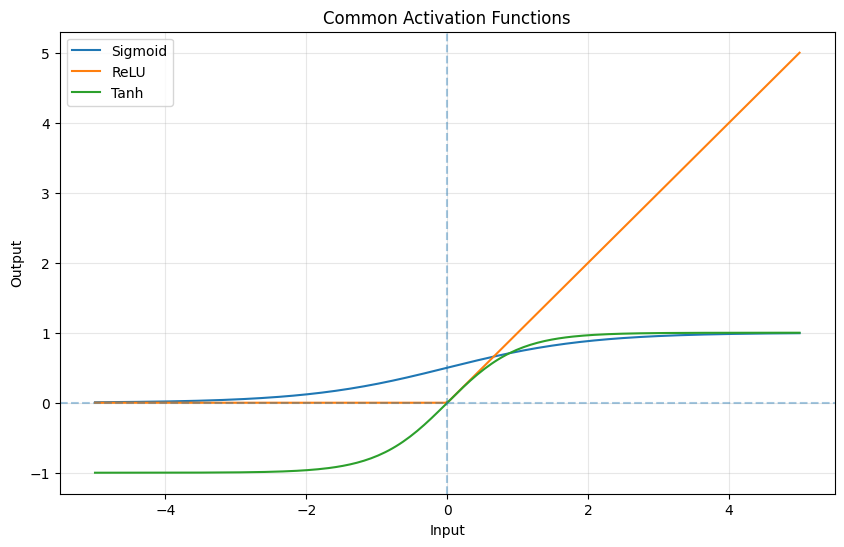

In [10]:
sigmoid_y = 1 / (1 + np.exp(-x))
relu_y = np.maximum(0, x)
tanh_y = np.tanh(x)

plt.figure(figsize=(10, 6))

plt.plot(x, sigmoid_y, label="Sigmoid")
plt.plot(x, relu_y, label="ReLU")
plt.plot(x, tanh_y, label="Tanh")

plt.axhline(0, linestyle="--", alpha=0.4)
plt.axvline(0, linestyle="--", alpha=0.4)

plt.title("Common Activation Functions")
plt.xlabel("Input")
plt.ylabel("Output")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Questions

1. Which activation outputs values between 0 and 1?
2. Which activation keeps positive values unchanged?
3. Which activation outputs values between -1 and 1?
4. Which activation would you use for binary classification?

### Answers
1. Sigmoid activation outputs values is between 0 and 1.
2. ReLU activation keeps positive values unchanged.
3. Tanh activation outputs values is between -1 and 1.
4. For binary classification, sigmoid activation is suitable due to the output range is between 0 and 1. 

## Part C — Build a Small Neural Network

We will train a neural network to classify two groups of points.

### Step 1 — Create a Dataset

In [14]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

X, y = make_moons(
    n_samples=400,
    noise=0.25,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_train[:10]

array([[ 0.47898636,  0.96035301],
       [ 2.18078733, -0.15299144],
       [ 1.82978889,  0.17962848],
       [ 0.41314607, -0.29959381],
       [ 1.11157234,  0.28406058],
       [ 0.82466792, -0.03605856],
       [ 0.31021356,  0.82738846],
       [-0.97910539,  0.39922287],
       [-0.69797603,  0.66254685],
       [ 0.10072044,  1.27917835]])

In [15]:
y_train[:10]

array([0, 1, 1, 1, 0, 1, 0, 0, 0, 0])

Look at the data.
* What type of ML problem is this?\
  It is binary classification.
* How many features does the dataset have?\
  The dataset have exact 2 features.

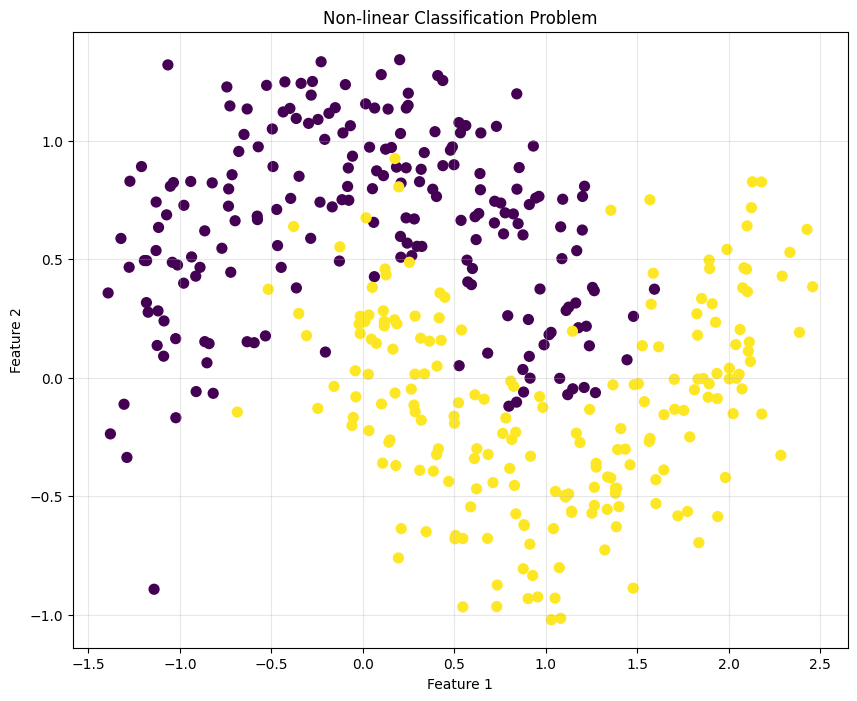

In [17]:
plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50)
plt.title("Non-linear Classification Problem")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True, alpha=0.3)
plt.show()

### Why this dataset?

This dataset cannot be easily separated by a straight line.

A neural network can learn a non-linear decision boundary.

Other simulated datasets [here](https://scikit-learn.org/stable/datasets/sample_generators.html#sample-generators).

## Part D — Train a Neural Network

Check the documentation for [MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html).

In [18]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8083333333333333


## Part E — Visualize the Decision Boundary

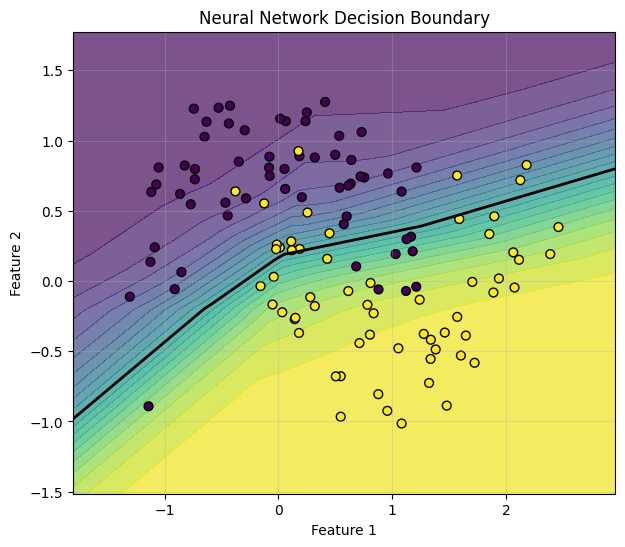

In [19]:
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:, 1]
    probs = probs.reshape(xx.shape)

    plt.figure(figsize=(7, 6))

    # probability background
    plt.contourf(xx, yy, probs, levels=20, alpha=0.7)

    # decision boundary: probability = 0.5
    plt.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2)

    # data points
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, edgecolor="k")

    plt.title("Neural Network Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_decision_boundary(model, X_test, y_test)

### Questions

1. Is the decision boundary linear or non-linear?
2. Does the model separate the two classes well?
3. Where does it make mistakes?
4. Why is a neural network useful here?

### Answers
1. The decision boundary is non-linear since it is using ReLU activation.
2. The model seperate 2 classes with approximately 81% accurracy.
3. The model make mistakes in the noisy regions, the boundary cannot perfectly isolate the data in the noisy regions without becoming overfitting.
4. The neural network is useful since the data is not linearly seperated. By using ReLU to bend the decision boundary, it can flexibly fit the complex structure of the data.

## Part F — Training Over Epochs

Neural networks train over multiple epochs.

One epoch means: `one full pass through the training dataset`

### Train with Different Numbers of Epochs

In [24]:
epochs = [10, 50, 200, 1000]

for epoch in epochs:
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation="relu",
        max_iter=epoch,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Epochs: {epoch} | Accuracy: {acc:.3f}")

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Epochs: 10 | Accuracy: 0.467
Epochs: 50 | Accuracy: 0.683
Epochs: 200 | Accuracy: 0.817
Epochs: 1000 | Accuracy: 0.808


## Part G — Compare Different Network Sizes

In [21]:
architectures = [
    (2,),
    (10,),
    (50,),
    (50, 50)
]

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation="relu",
        max_iter=1000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Architecture: {arch} | Accuracy: {acc:.3f}")

Architecture: (2,) | Accuracy: 0.825
Architecture: (10,) | Accuracy: 0.808


C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Architecture: (50,) | Accuracy: 0.917
Architecture: (50, 50) | Accuracy: 0.933


### Questions

1. `architectures = [(2,), (10,), (50,), (50, 50)]`
What do these numbers mean? 10, (50, 50)?
2. What happens when the network has very few neurons?
3. What happens when the network has many neurons?
4. Which model seems best?
5. Can a neural network overfit?

### Answers
1. These numbers defines size and depth of hidden layers in the neuron network:\
   `(10,)`: Create a network with 1 hidden layer with 10 neurons.\
   `(50, 50)`: Create a network with 2 hidden layers, each layer contains 50 neurons.
2. The network with very few neurons often leads to underfitting.
3. The network with many neurons gain high capacity, it can bend, curve the decision boundary to learn complex model, non-linear relationships.
4. Base on the accurracy, the `(50, 50)` model is the best with 93.3% accurracy on the test set.
5. The neural network can overfit if you give it too much capacity. 

## Part H — Confusion Matrix

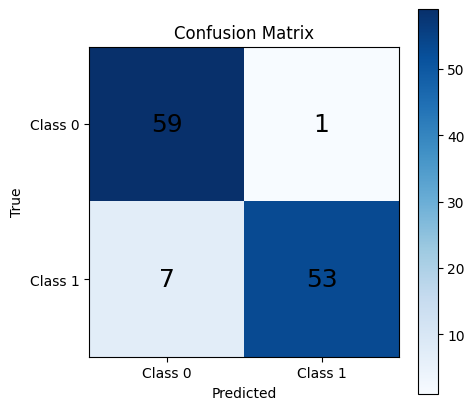

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap="Blues")

plt.xticks([0, 1], ["Class 0", "Class 1"])
plt.yticks([0, 1], ["Class 0", "Class 1"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=18)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.colorbar()
plt.show()

### Questions

Try and respond to these questions in a summarized manner.
1. What does a hidden layer do?
2. Why do we need activation functions?
3. What is the role of epochs?
4. What is the role of weights?
5. What happens if the network is too small?
6. What happens if the network is too large?

### Answers
1. Hidden layer take raw inputs and mathematically transform them into higher-level, more complex representations, allowing the network to learn intricate patterns.
2. Activation functions introduce non-linearity, which allow model to learn high-level, complex, real-world problems, without activation function, model act similarly to linear regression model.
3. Epoch is one pass over the entire dataset. Epochs are necessary because neural networks learn iteratively, improve over time and minimize loss and error.
4. Weight determines the importance of the connection between two neurons. They are actual parameters the network adjusts during training to figure out how to map inputs with outputs.
5. If the network is too small, it will lead to underfitting, the model lack of capacity to capture the underlying structure of data which leads to poor accurracy.
6. If the network is too large, it will lead to overfitting, the model has so much capacity that it starts memorizing the training data exactly, which fail when tested on new data, unseen data.

## For more complex coded neural networks, check:

* https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html